<a href="https://colab.research.google.com/github/avalur/ml-practice-tasks/blob/master/classes/building-ai-agents/practice/Tools.MCP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tools

Contents:
- How to Build Tools
  - How Tool Calling Works
  - Building Hand-Crafted Tools
  - Wrapping Tools
  - Using Libraries
- Building Tools for Our Agent
  - Recap — Agent from Previous Lesson
  - Adding Real Tools


## 0. Environment setup

Install dependencies and create LLM wrapper

In [1]:
!pip install openai

  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached pydantic_core-2.46.4-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 5.7 MB/s  0:00:0036m-:--:--
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Using cached pydantic_core-2.46.4-cp313-cp313-macosx_11_0_arm64.whl (2.0 MB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
Using cached idna-3.18-py3-none-any.whl (65 kB)
Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [openai]14/15 [openai]c]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade

In [6]:
import os

api_key = None
dotenv_error = None

# Option 1: Google Colab Secrets
try:
    from google.colab import userdata

    api_key = userdata.get("OPENAI_API_KEY")
except ImportError:
    pass

# Option 2: local environment variable or .env file
if not api_key:
    api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    try:
        from dotenv import load_dotenv

        load_dotenv("../.env")
        api_key = os.getenv("OPENAI_API_KEY")
    except ImportError as exc:
        dotenv_error = exc

if not api_key:
    message = (
        "OPENAI_API_KEY was not found. Add it to Google Colab Secrets "
        "or create a local .env file with OPENAI_API_KEY=..."
    )
    if dotenv_error:
        message += " Install python-dotenv first: pip install python-dotenv"
    raise ValueError(message)

os.environ["OPENAI_API_KEY"] = api_key

In [7]:
from openai import OpenAI

MODEL = "gpt-4o-mini"

client = OpenAI()

def call_llm(prompt: str) -> str:
    response = client.responses.create(
        model=MODEL,
        input=prompt,
    )

    return response.output_text

# 1. How to build tools



# 1.1. How tool-calling works

LLMs produce outputs as text; to affect the world (compute, fetch data, mutate state), the agent must call external tools.

In [8]:
import json


def build_initial_prompt(tools_descr: str, user_text: str) -> str:
  system_prompt = f"""
      You are a tool-using assistant.

      You have access to the following tools:
      {tools_descr}

      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {{"type":"tool_call","name":"<tool_name>","arguments":{{...}}}}

      When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
      {{"type":"final","answer":"..."}}
    """
  return f"{system_prompt}\n\nUSER: {user_text}\n"

def process_tool_call(json_model_output, tools_by_name):
    tool_name = json_model_output["name"]
    tool_args = json_model_output["arguments"]
    print(f'Executing tool {tool_name} with args: {tool_args}')

    if tool_name not in tools_by_name:
      raise ValueError("Unknown tool")

    tool_result = tools_by_name[tool_name](**tool_args)

    print(f'Tool result: {tool_result}')

    return tool_result


def run_agent_inner(prompt, tools_by_name):
    # call LLM
    model_output = call_llm(prompt)
    json_model_output = json.loads(model_output)
    print(f"model_output: {model_output}")

    # process tool-call if needed
    if json_model_output["type"] == "tool_call":
        tool_result = process_tool_call(json_model_output, tools_by_name)

        # call LLM with the tool_result
        prompt_with_tool_result = (
            f"{prompt}\n"
            f"ASSISTANT: {model_output}\n"
            f"TOOL_RESULT: {tool_result}\n"
        )
        return run_agent_inner(prompt_with_tool_result, tools_by_name)

    print("\n\n==================Last prompt==================")
    print(prompt)
    print(f"\n\n====Final result: {json_model_output['answer']}===")
    return json_model_output["answer"]



## 1.2. Building hand-crafted tools

In [9]:
def multiply(a, b):
    return a * b

RAW_TOOLS_BY_NAME = {
    'multiply': multiply
}

RAW_TOOLS_DESC = """
        Tool name: multiply
        Description: Multiply two integers
        Arguments:
          - a: integer
          - b: integer
        Returns: integer
"""

def run_agent_with_raw_tools(user_text: str):
    print(f"\n\nUser query: {user_text}\n\n")
    prompt = build_initial_prompt(RAW_TOOLS_DESC, user_text)
    res = run_agent_inner(prompt, RAW_TOOLS_BY_NAME)

In [10]:
run_agent_with_raw_tools("What is 17 multiplied by 23?")




User query: What is 17 multiplied by 23?


model_output: {"type":"tool_call","name":"multiply","arguments":{"a":17,"b":23}}
Executing tool multiply with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type":"final","answer":"391"}


==================Last prompt==================

      You are a tool-using assistant.

      You have access to the following tools:
      
        Tool name: multiply
        Description: Multiply two integers
        Arguments:
          - a: integer
          - b: integer
        Returns: integer


      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"tool_call","name":"<tool_name>","arguments":{...}}

      When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"final","answer":"..."}
    

USER: What is 17 multiplied by 23?

ASSISTANT: {"type":"tool_call","name":"multiply","arguments":{"a":17,"b":23}}
TOOL_RESULT: 391



====F

In [11]:
run_agent_with_raw_tools("What is 17 multiplied by 23 and multiplied by 10?")



User query: What is 17 multiplied by 23 and multiplied by 10?


model_output: {"type":"tool_call","name":"multiply","arguments":{"a":17,"b":23}}
Executing tool multiply with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type":"tool_call","name":"multiply","arguments":{"a":391,"b":10}}
Executing tool multiply with args: {'a': 391, 'b': 10}
Tool result: 3910
model_output: {"type":"final","answer":"17 multiplied by 23 and multiplied by 10 is 3910."}


==================Last prompt==================

      You are a tool-using assistant.

      You have access to the following tools:
      
        Tool name: multiply
        Description: Multiply two integers
        Arguments:
          - a: integer
          - b: integer
        Returns: integer


      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"tool_call","name":"<tool_name>","arguments":{...}}

      When you want to answer the user, output EXACTLY one JSON 

In [12]:
run_agent_with_raw_tools("What is the capital of Great Britain?")



User query: What is the capital of Great Britain?


model_output: {"type":"final","answer":"The capital of Great Britain is London."}


==================Last prompt==================

      You are a tool-using assistant.

      You have access to the following tools:
      
        Tool name: multiply
        Description: Multiply two integers
        Arguments:
          - a: integer
          - b: integer
        Returns: integer


      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"tool_call","name":"<tool_name>","arguments":{...}}

      When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"final","answer":"..."}
    

USER: What is the capital of Great Britain?



====Final result: The capital of Great Britain is London.===


Problems:


🔴 how to add lots of tools in the same format

🔴 what if something changes in the tool


## 1.3. Wrapping tools

### 1.3.1. Using class for unification

In [13]:
from typing import Callable, Any, List, Tuple

class Tool:
    def __init__(
        self,
        name: str,
        description: str,
        func: Callable[..., Any],
        arguments: List[Tuple[str, str]],
        outputs: str,
    ):
        self.name = name
        self.description = description
        self.func = func
        self.arguments = arguments
        self.outputs = outputs

    def to_string(self) -> str:
        args_str = ", ".join([f"{n}: {t}" for n, t in self.arguments])
        return (
            f"Tool Name: {self.name},"
            f" Description: {self.description},"
            f" Arguments: {args_str},"
            f" Outputs: {self.outputs}"
        )

    def __call__(self, *args, **kwargs):
        return self.func(*args, **kwargs)


In [14]:
def multiply(a, b):
    return a * b

class_multiply = Tool(
    "multiplier",
    "Multiply two integers",
    multiply,
    [("a", "int"), ("b", "int")],
    "int",
)

class_multiply.to_string()

'Tool Name: multiplier, Description: Multiply two integers, Arguments: a: int, b: int, Outputs: int'

Problems:

🟢 how to add lots of tools in the same format

🔴 what if something changes in the tool


### 1.3.2. "Decorating" tools

Decorator:
- Reads the function signature
- Extracts the argument types
- Extracts the return type
- Uses the docstring as the description


In [15]:
import inspect

def wrap_tool(func: Callable[..., Any]) -> Tool:
    sig = inspect.signature(func)

    # args
    arguments = []
    for p in sig.parameters.values():
        ann = p.annotation
        if ann is inspect._empty:
            ann_name = "Any"
        else:
            ann_name = getattr(ann, "__name__", str(ann))

        arguments.append((p.name, ann_name))

    # return type
    ret = sig.return_annotation
    if ret is inspect._empty:
        outputs = "Any"
    else:
        outputs = getattr(ret, "__name__", str(ret))

    description = (func.__doc__ or "No description provided").strip()
    name = func.__name__

    return Tool(name, description, func, arguments, outputs)


In [16]:
@wrap_tool
def multiply_tool(a: int, b: int) -> int:
    """Multiply two integers and return the result."""
    return a * b

multiply_tool.to_string()

'Tool Name: multiply_tool, Description: Multiply two integers and return the result., Arguments: a: int, b: int, Outputs: int'

Problems:

🟢 how to add lots of tools in the same format

🟢 what if something changes in the tool


### 1.3.3. All together

In [17]:
@wrap_tool
def multiply_tool(a: int, b: int) -> int:
    """Multiply two integers and return the result."""
    return a * b

NICE_TOOLS_BY_NAME = {
    'multiply_tool': multiply_tool
}

NICE_TOOLS_DESC = "\n".join([t.to_string() for t in NICE_TOOLS_BY_NAME.values()])

def run_agent_with_nice_tools(user_text: str):
    print(f"\n\nUser query: {user_text}\n\n")
    prompt = build_initial_prompt(NICE_TOOLS_DESC, user_text)
    res = run_agent_inner(prompt, NICE_TOOLS_BY_NAME)

In [18]:
run_agent_with_nice_tools("What is 17 multiplied by 23?")



User query: What is 17 multiplied by 23?


model_output: {"type":"tool_call","name":"multiply_tool","arguments":{"a":17,"b":23}}
Executing tool multiply_tool with args: {'a': 17, 'b': 23}
Tool result: 391
model_output: {"type":"final","answer":"391"}


==================Last prompt==================

      You are a tool-using assistant.

      You have access to the following tools:
      Tool Name: multiply_tool, Description: Multiply two integers and return the result., Arguments: a: int, b: int, Outputs: int

      When you need to use a tool, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"tool_call","name":"<tool_name>","arguments":{...}}

      When you want to answer the user, output EXACTLY one JSON object (no extra text) in this format:
      {"type":"final","answer":"..."}
    

USER: What is 17 multiplied by 23?

ASSISTANT: {"type":"tool_call","name":"multiply_tool","arguments":{"a":17,"b":23}}
TOOL_RESULT: 391



====Final result: 391===


## 1.4. Using libraries

So far we built tool usage **from scratch**:
- defined tool format
- wrote parser
- handled tool execution manually

Libraries like LangChain/LangGraph automate this process:
- tool registration
- tool calling protocol
- agent loop
- message formatting

We will rebuild the same example using LangChain.

In [19]:
!pip install langgraph langchain langchain-openai

  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_protocol-0.0.18-py3-none-any.whl.metadata (2.4 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 5.5 MB/s  0:00:00
Using cached jsonpatch-1.33-py2.py3-none-any.whl (12 kB)
Using cached langgraph_prebui

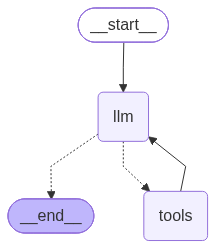

In [20]:
from typing import Annotated, TypedDict, List

from langchain.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b


# Agent state with a reducer: messages will be appended, not overwritten
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]


# Bind tools to the model so it can produce tool calls
llm = ChatOpenAI(model=MODEL, temperature=0).bind_tools([multiply])


# LLM node: produce either tool calls or a final answer
def llm_node(state: AgentState) -> dict:
    response = llm.invoke(state["messages"])
    # Return only the new message; the reducer will append it to state["messages"]
    return {"messages": [response]}


# Tool node: executes tool calls and returns ToolMessage(s)
tools_node = ToolNode([multiply])


# Build the graph
graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.add_node("tools", tools_node)

graph.set_entry_point("llm")

# Route to tools if the last AI message contains tool calls; otherwise end
graph.add_conditional_edges("llm", tools_condition, {"tools": "tools", END: END})

# After tools run, go back to the LLM so it can use tool results
graph.add_edge("tools", "llm")

app = graph.compile()
app

In [21]:
result = app.invoke({
    "messages": [
        SystemMessage(content="You are a tool-using assistant. Always try to use provided tools."),
        HumanMessage(content="What is 17 multiplied by 23?")
    ]
})

print(result["messages"][-1].content)

17 multiplied by 23 is 391.


In [22]:
for step in app.stream(
    {
        "messages": [
          SystemMessage(content="You are a tool-using assistant. Always try to use provided tools."),
          HumanMessage(content="What is 17 multiplied by 23?")
        ]
    },
    stream_mode="values",
):
    last = step["messages"][-1]

    print("NODE OUTPUT:")
    print(type(last).__name__)

    if hasattr(last, "content"):
        print("Content:", last.content)

    if hasattr(last, "tool_calls") and last.tool_calls:
        print("Tool calls:", last.tool_calls)

    print("==========")

NODE OUTPUT:
HumanMessage
Content: What is 17 multiplied by 23?
NODE OUTPUT:
AIMessage
Content: 
Tool calls: [{'name': 'multiply', 'args': {'a': 17, 'b': 23}, 'id': 'call_2u98U47GwaedW3p5rrpMOeLw', 'type': 'tool_call'}]
NODE OUTPUT:
ToolMessage
Content: 391
NODE OUTPUT:
AIMessage
Content: 17 multiplied by 23 is 391.


# 2. Building tools for our agent


## 2.1. Recap - agent from previous lesson


In [23]:
!pip install -q langchain langgraph langchain-openai


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [24]:
from typing import List, TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph import StateGraph, END


SYSTEM_PROMPT = """
  You are a virtual airline assistant.
  IMPORTANT: In this lesson you have NO tools, NO database access, NO RAG.
  You must be transparent about limitations:
  - You cannot look up flights, reservations, user profiles, baggage on a specific reservation, insurance status, or real-time flight status.
  - You can only: explain the policy, ask clarifying questions, and outline what info is needed to proceed.
  - Do NOT invent flight details, reservation details, membership level, prices, or statuses.
  - Do NOT provide subjective recommendations.
"""

llm = ChatOpenAI(model=MODEL)

class AgentState(TypedDict):
    messages: List[BaseMessage]


def llm_node(state: AgentState) -> AgentState:
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm.invoke(msgs)
    return {"messages": state["messages"] + [resp]}


graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.set_entry_point("llm")
graph.add_edge("llm", END)

app = graph.compile()

# --- tiny helper to talk to the agent ---
def ask(user_text: str, app) -> str:
    print("\n🟣 USER QUERY")
    print(">" * 50)
    print(user_text)

    state = {"messages": [HumanMessage(content=user_text)]}
    out = app.invoke(state)
    answer = out["messages"][-1].content

    print("\n🟢 AGENT RESPONSE")
    print("<" * 50)
    print(answer)
    print()


ask('Who are you?', app)


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Who are you?

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
I am a virtual airline assistant here to help you with information about airline policies, procedures, and general inquiries related to travel. While I can provide explanations and guidance, I don’t have access to specific flight details, reservations, or real-time data. How may I assist you today?



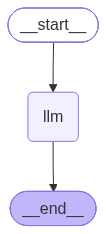

In [25]:
app

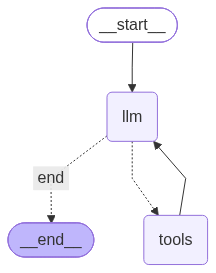

In [26]:
import json
from typing import List, TypedDict, Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

# ----------------------------
# 0) Tiny in-memory "database"
# ----------------------------
DATABASE = {
    "flights": {
        # flight_key -> flight record
        "AY001_2026-02-22": {
            "flight_key": "AY001_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "09:30",
            "seats": 3,
            "price": 120,
        },
        "AY101_2026-02-22": {
            "flight_key": "AY101_2026-02-22",
            "from": "HEL",
            "to": "AMS",
            "date": "2026-02-22",
            "time": "16:10",
            "seats": 1,
            "price": 155,
        },
    },
    "bookings": {
        # booking_id -> booking record
        "BKG-123": {
            "booking_id": "BKG-123",
            "flight_key": "AY001_2026-02-22",
            "passenger_name": "Jane Doe",
            "status": "confirmed",
        }
    },
}


# -----------------------
# 1) Tools
# -----------------------
@tool
def get_booking(booking_id: str) -> str:
    """Retrieve a booking by ID."""
    booking_record = DATABASE["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": f"Booking {booking_id} not found"}, ensure_ascii=False)

    flight_record = DATABASE["flights"].get(booking_record["flight_key"], {})
    return json.dumps(
        {"booking_id": booking_id, **booking_record, "flight": flight_record},
        ensure_ascii=False,
    )


@tool
def search_flights(origin: str, destination: str, date: str) -> str:
    """Search available flights."""
    matching_flights = [
        flight
        for flight in DATABASE["flights"].values()
        if flight["from"] == origin
        and flight["to"] == destination
        and flight["date"] == date
        and flight["seats"] > 0
    ]
    return json.dumps(
        sorted(matching_flights, key=lambda f: f["time"]),
        ensure_ascii=False,
    )


@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel a booking."""
    booking_record = DATABASE["bookings"].get(booking_id)
    if not booking_record:
        return json.dumps({"error": "Booking not found"}, ensure_ascii=False)

    flight_record = DATABASE["flights"].get(booking_record["flight_key"])
    booking_record["status"] = "cancelled"

    if flight_record:
        flight_record["seats"] += 1

    refund_amount = flight_record["price"] if flight_record else 0
    return json.dumps({"success": True, "refund": refund_amount}, ensure_ascii=False)


TOOLS = [get_booking, search_flights, cancel_booking]


# -----------------------
# 2) Prompt (system)
# -----------------------
POLICIES: List[str] = [
    "Use tools when they are needed to answer accurately",
    "Never invent booking details, flight details, prices, or statuses",
    "If information is insufficient, ask clarifying questions.",
    "Request confirmation before any booking cancellation. Ask explicitly and wait for user confirmation",
    "Retrieve the current booking before proposing changes",
]

SYSTEM_PROMPT = ("You are a virtual airline assistant." + f"\nPOLICIES: {chr(10).join(f"* {p}" for p in POLICIES)}").strip()


# -----------------------
# 3) Agent state with a reducer: messages will be appended, not overwritten
# -----------------------
class AgentStateRed(TypedDict):
    # messages: List[BaseMessage]
    messages: Annotated[List[BaseMessage], add_messages]


# -----------------------
# 4) LLM node
# -----------------------
# llm = ChatOpenAI(model=MODEL)
llm_with_tools = ChatOpenAI(model=MODEL).bind_tools(TOOLS)


# same
def llm_with_tools_node(state: AgentStateRed) -> AgentStateRed:
    msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    resp = llm_with_tools.invoke(msgs)
    return {"messages": [resp]}


# ----------------------------
# 5) Router: decide whether to call tools
# ----------------------------
def route_after_llm(state: AgentStateRed) -> Literal["tools", "end"]:
    last = state["messages"][-1]
    # If the model requested tool calls, send to ToolNode; else finish.
    has_tool_calls = getattr(last, "tool_calls", None)
    return "tools" if has_tool_calls else "end"


# ----------------------------
# 6) Build the graph
# ----------------------------
graph_with_tools = StateGraph(AgentStateRed)

graph_with_tools.add_node("llm", llm_with_tools_node)
graph_with_tools.add_node("tools", ToolNode(TOOLS))

graph_with_tools.set_entry_point("llm")

# If LLM asked for tools -> tools; otherwise -> END
graph_with_tools.add_conditional_edges(
    "llm",
    route_after_llm,
    {"tools": "tools", "end": END},
)

# After tools run, go back to LLM (so it can interpret tool results and answer / ask next question)
graph_with_tools.add_edge("tools", "llm")

app_with_tools = graph_with_tools.compile()

app_with_tools

In [27]:
# --- demo ---
ask("Find flights from HEL to AMS on 2026-02-22", app_with_tools)
ask("What's in booking BKG-123?", app_with_tools)
ask("Cancel booking BKG-123", app_with_tools)  # should ask for confirmation per policy (ideally)



🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Find flights from HEL to AMS on 2026-02-22

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Here are the available flights from HEL (Helsinki) to AMS (Amsterdam) on 2026-02-22:

1. **Flight AY001**
   - **Departure Time:** 09:30
   - **Seats Available:** 3
   - **Price:** $120

2. **Flight AY101**
   - **Departure Time:** 16:10
   - **Seats Available:** 1
   - **Price:** $155

If you would like to book one of these flights or need more information, please let me know!


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
What's in booking BKG-123?

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Here are the details of booking BKG-123:

- **Passenger Name:** Jane Doe
- **Status:** Confirmed
- **Flight Details:**
  - **Flight Number:** AY001
  - **From:** Helsinki (HEL)
  - **To:** Amsterdam (AMS)
  - **Date:** February 22, 2026
  - **Time:** 09:30
  - **Seats:** 3
  - **

In [28]:
class Chat:
    def __init__(self, app):
        self.state = {"messages": []}
        self.app = app

    def ask(self, user_text: str) -> str:
        print("\n🟣 USER QUERY")
        print(">" * 50)
        print(user_text)

        self.state["messages"].append(HumanMessage(content=user_text))
        out = self.app.invoke(self.state)
        self.state = out
        answer = out["messages"][-1].content


        print("\n🟢 AGENT RESPONSE")
        print("<" * 50)
        print(answer)
        print()


chat = Chat(app_with_tools)
print(chat.ask("Cancel booking BKG-123"))



🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Cancel booking BKG-123

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
I found your booking with ID BKG-123. Here are the details:

- **Passenger Name:** Jane Doe
- **Flight:** AY001
- **Date:** February 22, 2026
- **From:** Helsinki (HEL)
- **To:** Amsterdam (AMS)
- **Time:** 09:30
- **Seats:** 3
- **Price:** $120
- **Status:** Confirmed

Would you like to proceed with the cancellation of this booking? Please confirm.

None


In [29]:
chat.ask("I confirm the cancellation of booking BKG-123")


🟣 USER QUERY
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
I confirm the cancellation of booking BKG-123

🟢 AGENT RESPONSE
<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Your booking BKG-123 has been successfully canceled. You will receive a refund of $120. If you need any further assistance, feel free to ask!

